In [1]:
# %%
import os

# Limit threads to prevent OpenMP segfaults on clusters
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Disable HDF5 file locking so we can read while the cluster is writing
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

# Paths to your extracted HDF5 files (now pointing to the restructured folder)
H5_DIR = BASE_DIR / "data/embeddings"

MODEL_FILES = {
    "base": H5_DIR / "ofd_base_20260226-204726.h5",
    "tail": H5_DIR / "ofd_tail_20260226-204729.h5",
    "tailhip": H5_DIR / "ofd_tailhip_20260226-205043.h5"
}

SELECTED_MODEL = "tailhip"
h5_path = MODEL_FILES[SELECTED_MODEL]

print(f"Using file: {h5_path}")

Using file: /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/embeddings/ofd_tailhip_20260226-205043.h5


Video: HDP-002539_HAB_Adult_371
Stage 1 shape: (34003, 128)
Stage 2 shape: (34003, 192)
Stage 3 shape: (34003, 256)


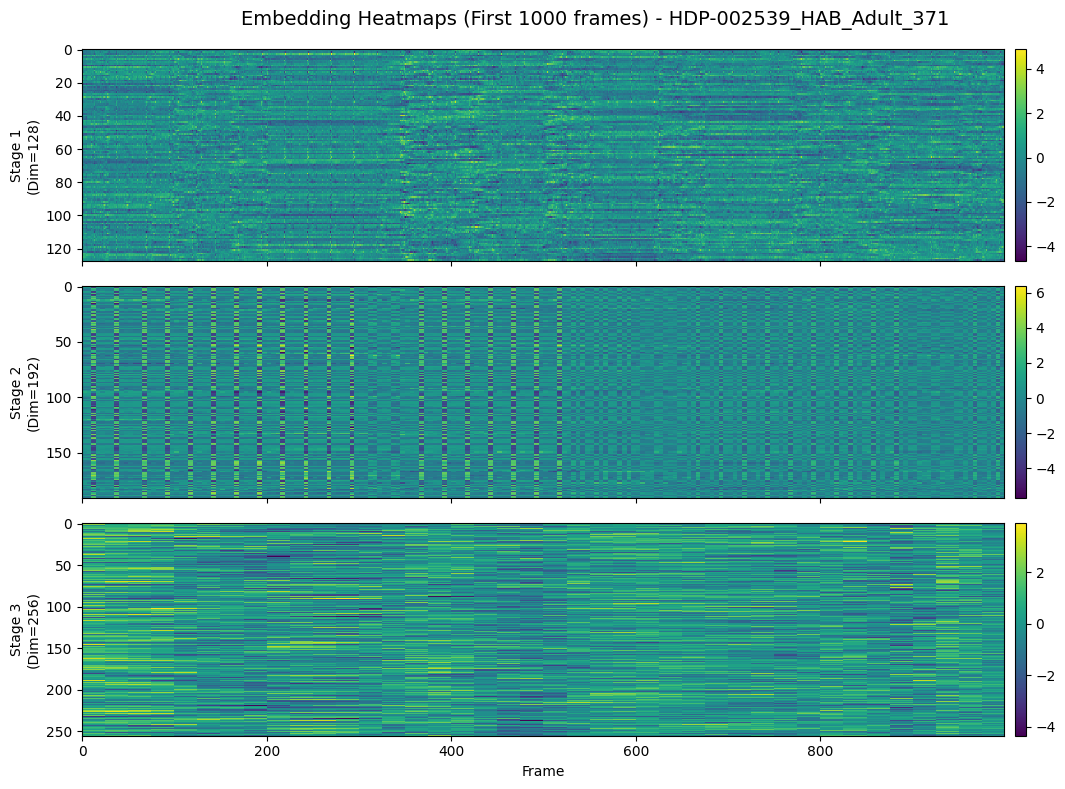

In [7]:
# %%
# Open the HDF5 file and grab the first video
with h5py.File(h5_path, 'r') as f:
    video_names = list(f.keys())
    test_vid = video_names[0]
    
    vid_group = f[test_vid]
    # Load the 3 stages into memory
    s1 = vid_group["stage1"][:]
    s2 = vid_group["stage2"][:]
    s3 = vid_group["stage3"][:]
    
print(f"Video: {test_vid}")
print(f"Stage 1 shape: {s1.shape}")
print(f"Stage 2 shape: {s2.shape}")
print(f"Stage 3 shape: {s3.shape}")

# Standardize for visualization
scaler = StandardScaler()
s1_scaled = scaler.fit_transform(s1)
s2_scaled = scaler.fit_transform(s2)
s3_scaled = scaler.fit_transform(s3)

# Plot Heatmaps for the first 1000 frames
T_vis = min(1000, s1.shape[0])

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, emb, name in zip(axes, [s1_scaled, s2_scaled, s3_scaled], ["Stage 1", "Stage 2", "Stage 3"]):
    im = ax.imshow(emb[:T_vis].T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_ylabel(f"{name}\n(Dim={emb.shape[1]})")
    plt.colorbar(im, ax=ax, pad=0.01)

axes[-1].set_xlabel("Frame")
plt.suptitle(f"Embedding Heatmaps (First {T_vis} frames) - {test_vid}", fontsize=14)
plt.tight_layout()
plt.show()

Subsampling 10000 frames from 50 videos...
stage1 subsampled shape: (466480, 128)
stage2 subsampled shape: (466480, 192)
stage3 subsampled shape: (466480, 256)
Clustering stage1...
Clustering stage2...
Clustering stage3...


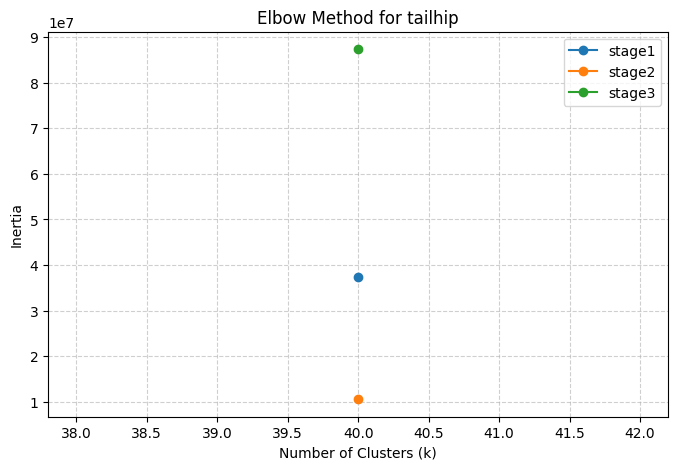

In [8]:
# %%
N_VIDEOS = 50
N_FRAMES_PER_VID = 10000

print(f"Subsampling {N_FRAMES_PER_VID} frames from {N_VIDEOS} videos...")

subsampled_stages = {"stage1": [], "stage2": [], "stage3": []}

with h5py.File(h5_path, 'r') as f:
    vids_to_sample = np.random.choice(video_names, min(N_VIDEOS, len(video_names)), replace=False)
    
    for vid in vids_to_sample:
        group = f[vid]
        T = group.attrs["num_frames"]
        
        # Random frame indices
        idx = np.sort(np.random.choice(T, min(N_FRAMES_PER_VID, T), replace=False))
        
        subsampled_stages["stage1"].append(group["stage1"][idx, :])
        subsampled_stages["stage2"].append(group["stage2"][idx, :])
        subsampled_stages["stage3"].append(group["stage3"][idx, :])

# Concatenate and standardize
scaled_subs = {}
for stage, data in subsampled_stages.items():
    concatenated = np.vstack(data)
    scaled_subs[stage] = StandardScaler().fit_transform(concatenated)
    print(f"{stage} subsampled shape: {scaled_subs[stage].shape}")

# --- Run Elbow Method ---
k_range = [ 40 ]
inertias = {"stage1": [], "stage2": [], "stage3": []}

for stage, data in scaled_subs.items():
    print(f"Clustering {stage}...")
    for k in k_range:
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=3)
        km.fit(data)
        inertias[stage].append(km.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 5))
for stage, values in inertias.items():
    plt.plot(k_range, values, marker='o', label=stage)
plt.title(f"Elbow Method for {SELECTED_MODEL}")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [9]:
# %%
# Choose your optimal K
OPTIMAL_K = 40 

kmeans_models = {}
for stage, data in scaled_subs.items():
    km = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42, batch_size=4096, n_init=10)
    km.fit(data) # Fit on the subsample
    kmeans_models[stage] = km

# Predict labels for our test video (the one we plotted in Cell 2)
# We use the same scalers from Cell 2
hbmae_labels = {
    "stage1": kmeans_models["stage1"].predict(s1_scaled),
    "stage2": kmeans_models["stage2"].predict(s2_scaled),
    "stage3": kmeans_models["stage3"].predict(s3_scaled)
}

print(f"Assigned labels for {test_vid}: {hbmae_labels['stage1'].shape}")

Assigned labels for HDP-002539_HAB_Adult_371: (34003,)


In [2]:
# %%
import keypoint_moseq as kpms
import pickle


from pathlib import Path

# Ensure PROJECT_ROOT is defined (if it isn't already in this specific cell)
PROJECT_ROOT = Path("/scratch/michal/projects/dvc_ofd_2025")

shuffle = 3
projset = 0
modset = 0

kpms_project_path = PROJECT_ROOT / f"data/interim/keypoint_moseq_project/shuffle-{shuffle}_projset-{projset}"
model_name = f"shuffle-{shuffle}_projset-{projset}_modset-{modset}"

# Load config and results
config = kpms.load_config(os.path.join(kpms_project_path, model_name))
results_path = os.path.join(kpms_project_path, model_name, "results.h5")

print(f"Loading KPMS results from {results_path}...")
with h5py.File(results_path, 'r') as f:
    # f['syllable'] typically contains the labels. 
    # Alternatively, you can use the dictionary approach if you dumped them to a pickle.
    # Assuming 'test_vid' exists in KPMS:
    if test_vid in f:
        # Some KPMS setups store it under f[vid]['syllable']
        kpms_syllables = f[test_vid]['syllable'][:]
        print(f"Found KPMS syllables for {test_vid}! Shape: {kpms_syllables.shape}")
    else:
        # If the structure is different, let's just grab the first available video
        kpms_vid = list(f.keys())[0]
        if 'syllable' in f[kpms_vid]:
            kpms_syllables = f[kpms_vid]['syllable'][:]
            print(f"Could not find {test_vid}, using {kpms_vid} instead. Shape: {kpms_syllables.shape}")
            
            # Re-predict hBehaveMAE for THIS video to match
            with h5py.File(h5_path, 'r') as h5f:
                s1_new = StandardScaler().fit_transform(h5f[kpms_vid]["stage1"][:])
                hbmae_labels["stage1"] = kmeans_models["stage1"].predict(s1_new)
                hbmae_labels["stage2"] = kmeans_models["stage2"].predict(StandardScaler().fit_transform(h5f[kpms_vid]["stage2"][:]))
                hbmae_labels["stage3"] = kmeans_models["stage3"].predict(StandardScaler().fit_transform(h5f[kpms_vid]["stage3"][:]))

AttributeError: module 'jax.interpreters.pxla' has no attribute 'ShardedDeviceArray'

Comparing 34003 frames.
NMI Score: 0.158
ARI Score: 0.027


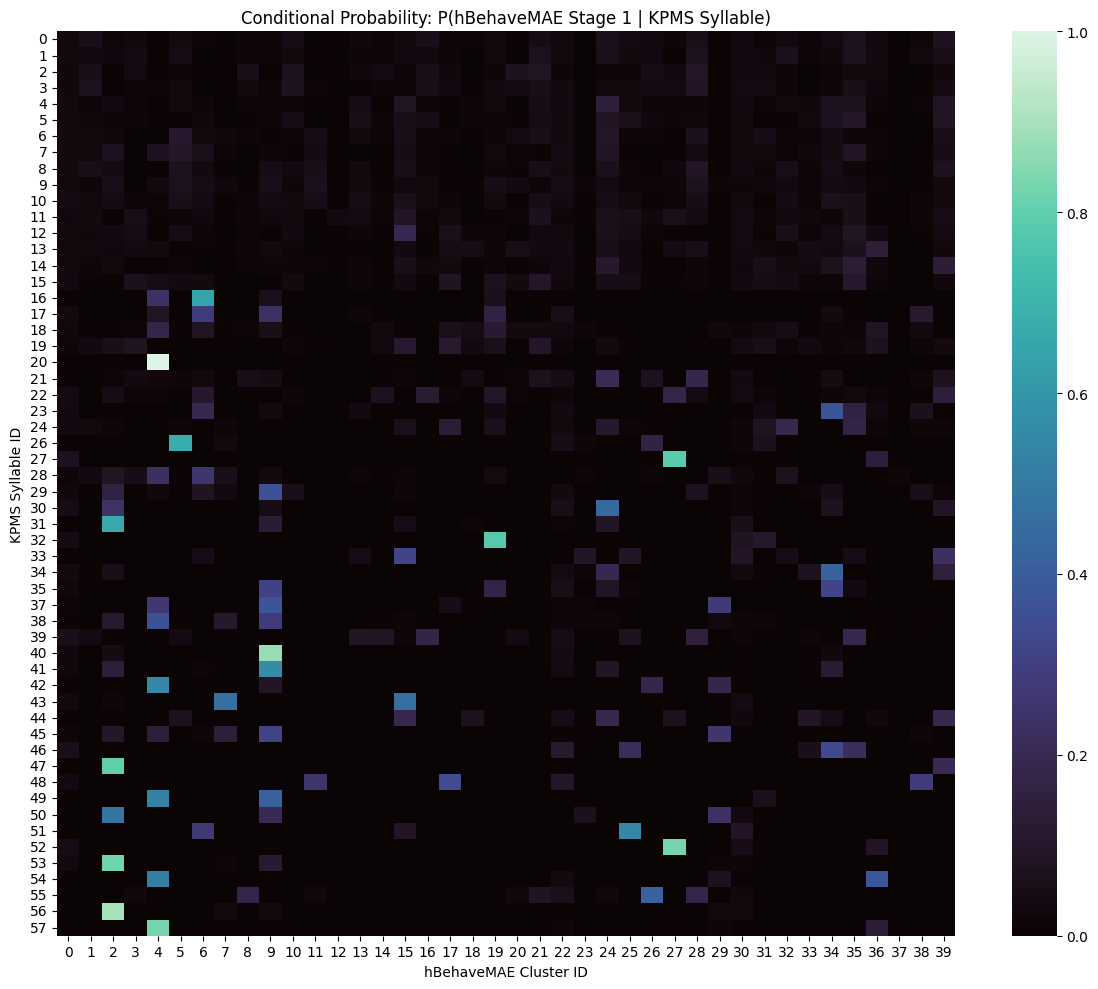

In [11]:
# %%
from sklearn.metrics import confusion_matrix

# Ensure arrays are the same length (sometimes KPMS trims a few frames)
min_len = min(len(kpms_syllables), len(hbmae_labels["stage1"]))
y_kpms = kpms_syllables[:min_len]
y_hbmae = hbmae_labels["stage1"][:min_len] # Let's compare Stage 1 first

print(f"Comparing {min_len} frames.")
print(f"NMI Score: {normalized_mutual_info_score(y_kpms, y_hbmae):.3f}")
print(f"ARI Score: {adjusted_rand_score(y_kpms, y_hbmae):.3f}")

# Compute overlap matrix (Confusion Matrix)
# Rows = KPMS Syllables, Cols = hBehaveMAE Clusters
overlap_matrix = confusion_matrix(y_kpms, y_hbmae)

# Normalize by row (KPMS syllable) to see conditional probability P(hBehaveMAE | KPMS)
row_sums = overlap_matrix.sum(axis=1, keepdims=True)
overlap_norm = np.divide(overlap_matrix, row_sums, out=np.zeros_like(overlap_matrix, dtype=float), where=row_sums!=0)

# Filter out empty KPMS syllables/clusters for a cleaner plot
active_kpms = np.where(row_sums > 0)[0]
active_hbmae = np.where(overlap_matrix.sum(axis=0) > 0)[0]
overlap_clean = overlap_norm[active_kpms][:, active_hbmae]

plt.figure(figsize=(12, 10))
sns.heatmap(overlap_clean, cmap="mako", 
            xticklabels=active_hbmae, yticklabels=active_kpms)
plt.title(f"Conditional Probability: P(hBehaveMAE Stage 1 | KPMS Syllable)")
plt.xlabel("hBehaveMAE Cluster ID")
plt.ylabel("KPMS Syllable ID")
plt.tight_layout()
plt.show()

Comparing 34003 frames.
NMI Score: 0.083
ARI Score: 0.014


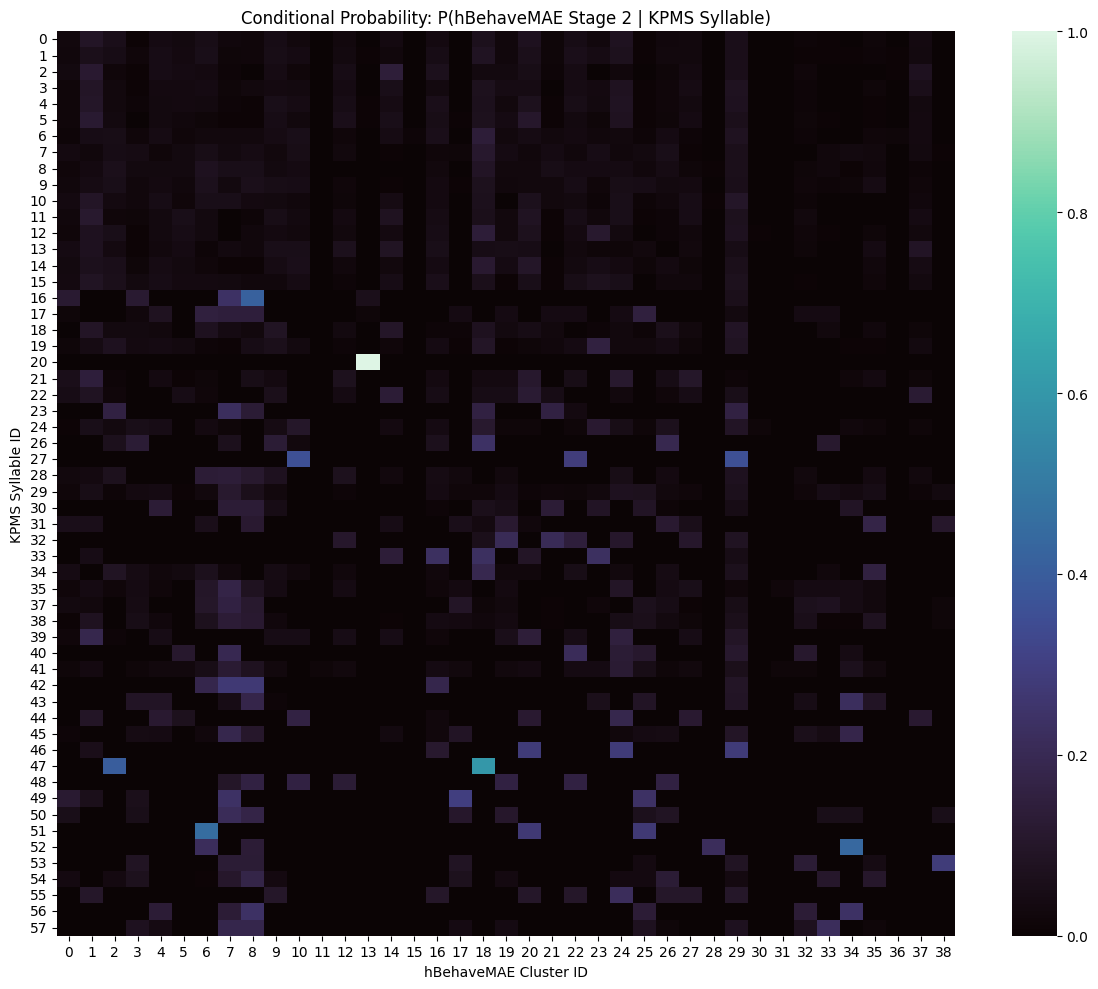

In [12]:
# %%
from sklearn.metrics import confusion_matrix

# Ensure arrays are the same length (sometimes KPMS trims a few frames)
min_len = min(len(kpms_syllables), len(hbmae_labels["stage2"]))
y_kpms = kpms_syllables[:min_len]
y_hbmae = hbmae_labels["stage2"][:min_len] # Let's compare Stage 2

print(f"Comparing {min_len} frames.")
print(f"NMI Score: {normalized_mutual_info_score(y_kpms, y_hbmae):.3f}")
print(f"ARI Score: {adjusted_rand_score(y_kpms, y_hbmae):.3f}")

# Compute overlap matrix (Confusion Matrix)
# Rows = KPMS Syllables, Cols = hBehaveMAE Clusters
overlap_matrix = confusion_matrix(y_kpms, y_hbmae)

# Normalize by row (KPMS syllable) to see conditional probability P(hBehaveMAE | KPMS)
row_sums = overlap_matrix.sum(axis=1, keepdims=True)
overlap_norm = np.divide(overlap_matrix, row_sums, out=np.zeros_like(overlap_matrix, dtype=float), where=row_sums!=0)

# Filter out empty KPMS syllables/clusters for a cleaner plot
active_kpms = np.where(row_sums > 0)[0]
active_hbmae = np.where(overlap_matrix.sum(axis=0) > 0)[0]
overlap_clean = overlap_norm[active_kpms][:, active_hbmae]

plt.figure(figsize=(12, 10))
sns.heatmap(overlap_clean, cmap="mako", 
            xticklabels=active_hbmae, yticklabels=active_kpms)
plt.title(f"Conditional Probability: P(hBehaveMAE Stage 2 | KPMS Syllable)")
plt.xlabel("hBehaveMAE Cluster ID")
plt.ylabel("KPMS Syllable ID")
plt.tight_layout()
plt.show()

Comparing 34003 frames.
NMI Score: 0.203
ARI Score: 0.041


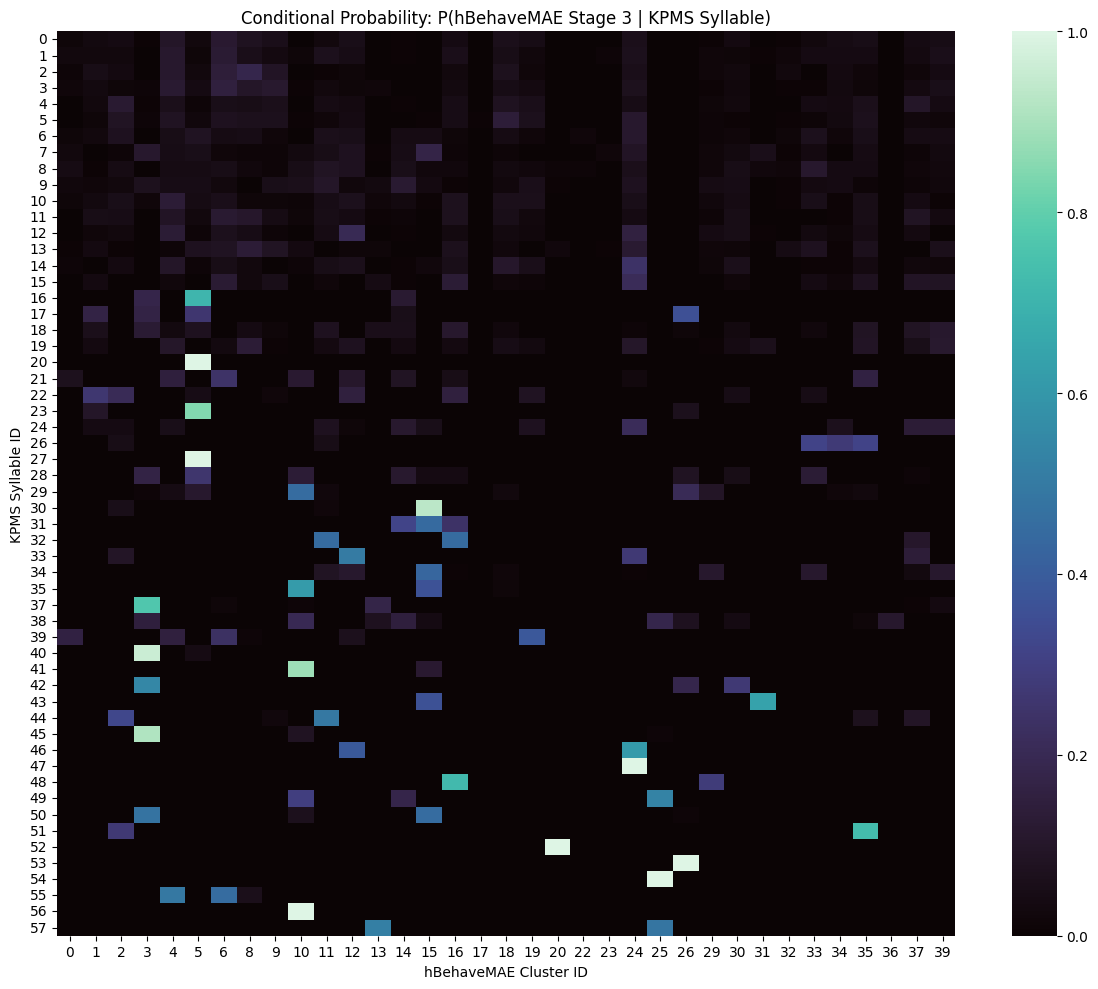

In [13]:
# %%
from sklearn.metrics import confusion_matrix

# Ensure arrays are the same length (sometimes KPMS trims a few frames)
min_len = min(len(kpms_syllables), len(hbmae_labels["stage3"]))
y_kpms = kpms_syllables[:min_len]
y_hbmae = hbmae_labels["stage3"][:min_len] # Let's compare Stage 3

print(f"Comparing {min_len} frames.")
print(f"NMI Score: {normalized_mutual_info_score(y_kpms, y_hbmae):.3f}")
print(f"ARI Score: {adjusted_rand_score(y_kpms, y_hbmae):.3f}")

# Compute overlap matrix (Confusion Matrix)
# Rows = KPMS Syllables, Cols = hBehaveMAE Clusters
overlap_matrix = confusion_matrix(y_kpms, y_hbmae)

# Normalize by row (KPMS syllable) to see conditional probability P(hBehaveMAE | KPMS)
row_sums = overlap_matrix.sum(axis=1, keepdims=True)
overlap_norm = np.divide(overlap_matrix, row_sums, out=np.zeros_like(overlap_matrix, dtype=float), where=row_sums!=0)

# Filter out empty KPMS syllables/clusters for a cleaner plot
active_kpms = np.where(row_sums > 0)[0]
active_hbmae = np.where(overlap_matrix.sum(axis=0) > 0)[0]
overlap_clean = overlap_norm[active_kpms][:, active_hbmae]

plt.figure(figsize=(12, 10))
sns.heatmap(overlap_clean, cmap="mako", 
            xticklabels=active_hbmae, yticklabels=active_kpms)
plt.title(f"Conditional Probability: P(hBehaveMAE Stage 3 | KPMS Syllable)")
plt.xlabel("hBehaveMAE Cluster ID")
plt.ylabel("KPMS Syllable ID")
plt.tight_layout()
plt.show()

Fetching KPMS syllables for the subsampled videos...
Global comparison on 466480 frames.
Global NMI Score: 0.064
Global ARI Score: 0.008


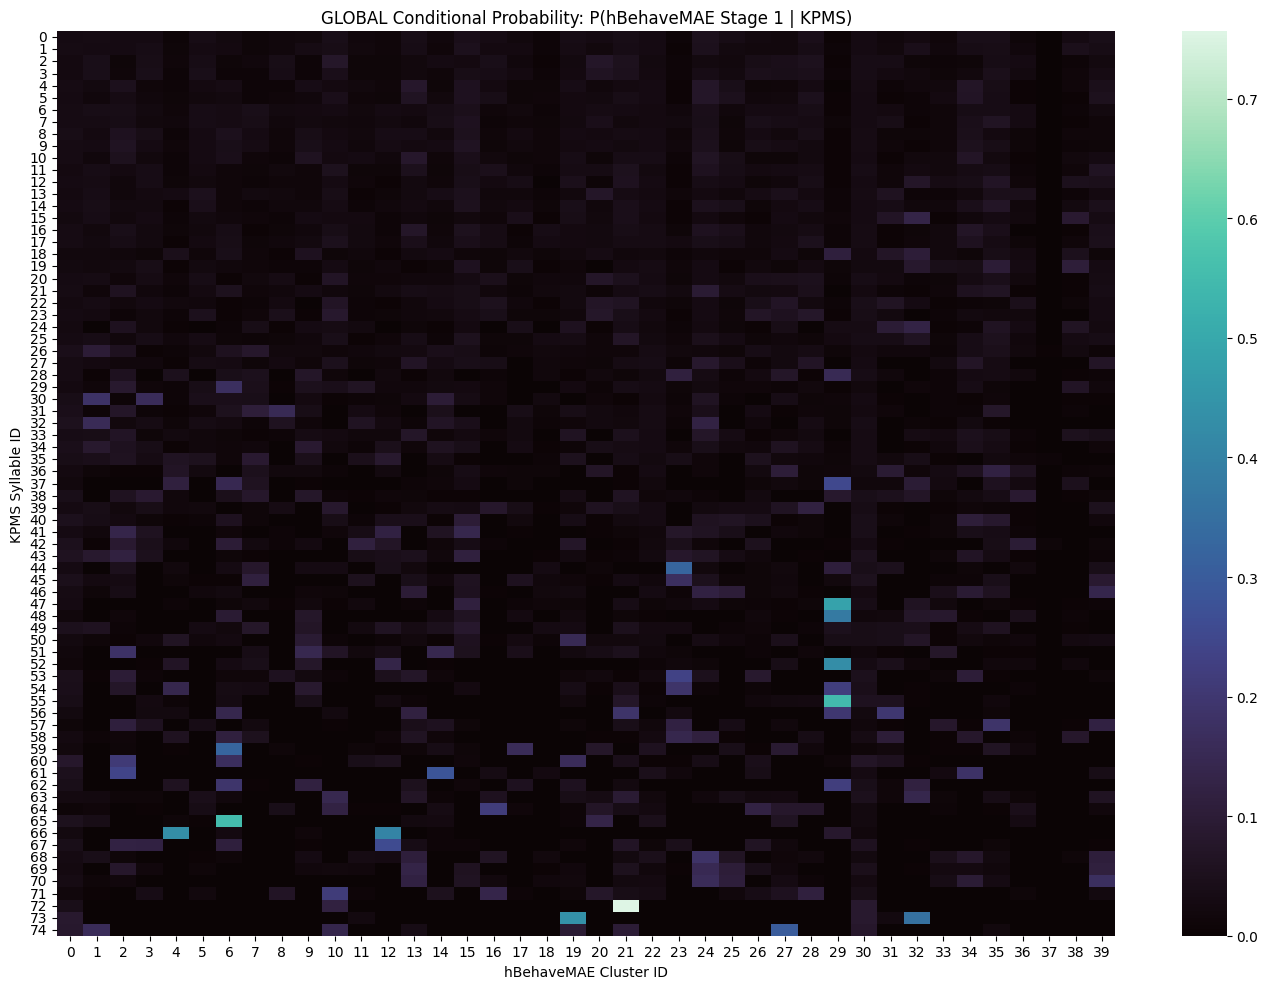

In [14]:
# %%
# We already have `scaled_subs` (hBehaveMAE embeddings) and `kmeans_models` from Cell 4
# Let's get the KPMS syllables for the exact same videos and frames

global_y_hbmae = kmeans_models["stage1"].labels_  # These are the labels for the subsample
global_y_kpms = []
valid_indices = [] # To keep track of which hBehaveMAE frames actually have KPMS counterparts

print("Fetching KPMS syllables for the subsampled videos...")

with h5py.File(results_path, 'r') as f_kpms:
    current_idx = 0
    for vid in vids_to_sample:
        with h5py.File(h5_path, 'r') as f_hbmae:
            T = f_hbmae[vid].attrs["num_frames"]
            
        # We used this exact same seed/logic in Cell 3 to sample the frames
        np.random.seed(42) # Ensure we get the same random frames (if you didn't set a seed in cell 3, we just re-slice)
        # Actually, since we didn't save the exact indices per video in cell 3, 
        # a safer way to do this globally is to just load a few full videos.
        
        if vid in f_kpms and 'syllable' in f_kpms[vid]:
            syls = f_kpms[vid]['syllable'][:]
            # We will just take the first N_FRAMES_PER_VID to make it simple and exact
            limit = min(N_FRAMES_PER_VID, len(syls), T)
            global_y_kpms.append(syls[:limit])
            
            # Re-predict hBehaveMAE for these exact frames
            with h5py.File(h5_path, 'r') as f_hbmae:
                s1_vid = f_hbmae[vid]["stage1"][:limit]
                s1_scaled = StandardScaler().fit_transform(s1_vid)
                global_y_hbmae_vid = kmeans_models["stage1"].predict(s1_scaled)
                valid_indices.append(global_y_hbmae_vid)

global_y_kpms = np.concatenate(global_y_kpms)
global_y_hbmae_aligned = np.concatenate(valid_indices)

print(f"Global comparison on {len(global_y_kpms)} frames.")
print(f"Global NMI Score: {normalized_mutual_info_score(global_y_kpms, global_y_hbmae_aligned):.3f}")
print(f"Global ARI Score: {adjusted_rand_score(global_y_kpms, global_y_hbmae_aligned):.3f}")

# Global Confusion Matrix
overlap_matrix = confusion_matrix(global_y_kpms, global_y_hbmae_aligned)
row_sums = overlap_matrix.sum(axis=1, keepdims=True)
overlap_norm = np.divide(overlap_matrix, row_sums, out=np.zeros_like(overlap_matrix, dtype=float), where=row_sums!=0)

active_kpms = np.where(row_sums > 0)[0]
active_hbmae = np.where(overlap_matrix.sum(axis=0) > 0)[0]
overlap_clean = overlap_norm[active_kpms][:, active_hbmae]

plt.figure(figsize=(14, 10))
sns.heatmap(overlap_clean, cmap="mako", xticklabels=active_hbmae, yticklabels=active_kpms)
plt.title(f"GLOBAL Conditional Probability: P(hBehaveMAE Stage 1 | KPMS)")
plt.xlabel("hBehaveMAE Cluster ID")
plt.ylabel("KPMS Syllable ID")
plt.tight_layout()
plt.show()

Found 27700 instances of Syllable 20
Extracted 626679 hBehaveMAE frames for this syllable.


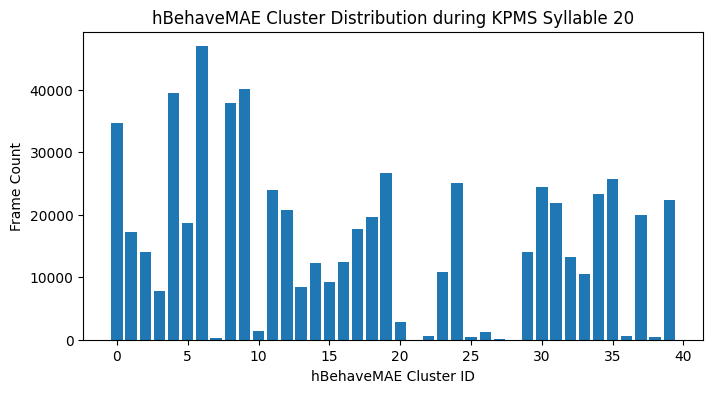

In [15]:
# %%
from keypoint_moseq import get_syllable_instances
import umap

TARGET_SYLLABLE = 20  

# 1. Get KPMS instances
with h5py.File(results_path, 'r') as f:
    syllables_dict = {k: v["syllable"][:] for k, v in f.items() if "syllable" in v}

instances = get_syllable_instances(
    syllables_dict,
    pre=0,         
    post=0,
    min_duration=5,
    min_frequency=0.005,
    min_instances=1
)

if TARGET_SYLLABLE not in instances:
    print(f"Syllable {TARGET_SYLLABLE} didn't meet the frequency/duration thresholds. Try another.")
else:
    syl_data = instances[TARGET_SYLLABLE]
    print(f"Found {len(syl_data)} instances of Syllable {TARGET_SYLLABLE}")
    
    # 2. Extract hBehaveMAE embeddings for these exact instances
    target_embeddings = []
    
    with h5py.File(h5_path, 'r') as f_hbmae:
        for inst in syl_data:
            # ---> THIS IS THE FIX: Unpack the tuple directly <---
            vid_name, start_frame, end_frame = inst 
            
            if vid_name in f_hbmae:
                # Grab stage 3 embeddings for this specific bout
                emb = f_hbmae[vid_name]["stage3"][start_frame:end_frame]
                target_embeddings.append(emb)
                
    if target_embeddings:
        target_embeddings = np.vstack(target_embeddings)
        print(f"Extracted {target_embeddings.shape[0]} hBehaveMAE frames for this syllable.")
        
        # 3. Predict which hBehaveMAE clusters these fall into
        target_scaled = StandardScaler().fit_transform(target_embeddings)
        pred_clusters = kmeans_models["stage3"].predict(target_scaled)
        
        unique, counts = np.unique(pred_clusters, return_counts=True)
        
        plt.figure(figsize=(8, 4))
        plt.bar(unique, counts)
        plt.title(f"hBehaveMAE Cluster Distribution during KPMS Syllable {TARGET_SYLLABLE}")
        plt.xlabel("hBehaveMAE Cluster ID")
        plt.ylabel("Frame Count")
        plt.show()

Evaluating base...
  -> NMI: 0.0292
Evaluating tail...
  -> NMI: 0.0333
Evaluating tailhip...
  -> NMI: 0.0355


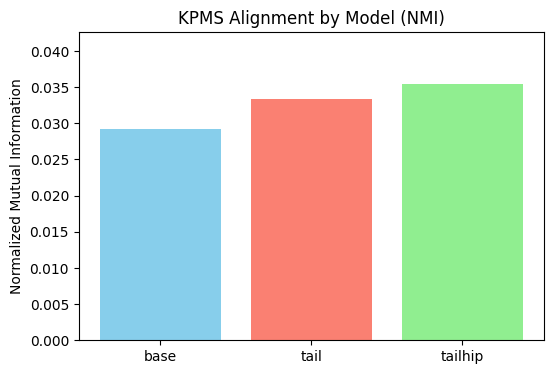

In [16]:
# %%
models_to_test = ["base", "tail", "tailhip"]
nmi_scores = {}

# We will use the same KPMS frames we extracted in Cell 7 (`global_y_kpms`)
# and just swap out the hBehaveMAE predictions.

for model in models_to_test:
    print(f"Evaluating {model}...")
    file_path = MODEL_FILES[model]
    
    valid_preds = []
    with h5py.File(file_path, 'r') as f_hbmae:
        for vid in vids_to_sample:
            if vid in f_hbmae and vid in syllables_dict:
                limit = min(N_FRAMES_PER_VID, len(syllables_dict[vid]), f_hbmae[vid].attrs["num_frames"])
                
                s1_vid = f_hbmae[vid]["stage1"][:limit]
                s1_scaled = StandardScaler().fit_transform(s1_vid)
                
                # Fit a quick MiniBatchKMeans just for this model
                km = MiniBatchKMeans(n_clusters=OPTIMAL_K, random_state=42, batch_size=4096, n_init=3)
                preds = km.fit_predict(s1_scaled)
                valid_preds.append(preds)
                
    if valid_preds:
        aligned_preds = np.concatenate(valid_preds)
        score = normalized_mutual_info_score(global_y_kpms, aligned_preds)
        nmi_scores[model] = score
        print(f"  -> NMI: {score:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(nmi_scores.keys(), nmi_scores.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title("KPMS Alignment by Model (NMI)")
plt.ylabel("Normalized Mutual Information")
plt.ylim(0, max(nmi_scores.values()) * 1.2)
plt.show()

In [3]:
#!/usr/bin/env python3
import os
import json
from pathlib import Path

# Limit threads for cluster safety
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import umap

from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

PROJECT_ROOT = Path("/scratch/michal/projects/dvc_ofd_2025")

# --- Configuration ---
H5_DIR = BASE_DIR / "data/embeddings"
KPMS_RESULTS = PROJECT_ROOT / "data/interim/keypoint_moseq_project/shuffle-3_projset-0/shuffle-3_projset-0_modset-0/results.h5"

# Route the outputs directly into your new clean results folder
OUTPUT_DIR = BASE_DIR / "results/analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = {
    "base": H5_DIR / "ofd_base_20260226-204726.h5",
    "tail": H5_DIR / "ofd_tail_20260226-204729.h5",
    "tailhip": H5_DIR / "ofd_tailhip_20260226-205043.h5"
}

N_VIDEOS = 100
N_FRAMES_PER_VID = 5000
K_RANGE = [40]


def load_aligned_data(model_path, kpms_path):
    """Loads hBehaveMAE embeddings and KPMS syllables, perfectly aligned."""
    hbmae_data = {"stage1": [], "stage2": [], "stage3": []}
    kpms_labels = []
    
    with h5py.File(model_path, 'r') as f_hbmae, h5py.File(kpms_path, 'r') as f_kpms:
        # Find videos present in both
        common_vids = [v for v in f_hbmae.keys() if v in f_kpms and 'syllable' in f_kpms[v]]
        
        # Subsample videos
        np.random.seed(42)
        vids_to_sample = np.random.choice(common_vids, min(N_VIDEOS, len(common_vids)), replace=False)
        
        for vid in vids_to_sample:
            syls = f_kpms[vid]['syllable'][:]
            T_hbmae = f_hbmae[vid].attrs["num_frames"]
            
            # The maximum frames we can safely compare
            max_valid_frames = min(len(syls), T_hbmae)
            
            # Randomly sample frames from this video
            idx = np.sort(np.random.choice(max_valid_frames, min(N_FRAMES_PER_VID, max_valid_frames), replace=False))
            
            kpms_labels.append(syls[idx])
            for stage in hbmae_data.keys():
                hbmae_data[stage].append(f_hbmae[vid][stage][idx, :])
                
    # Concatenate globally
    y_kpms = np.concatenate(kpms_labels)
    X_stages = {}
    for stage, data in hbmae_data.items():
        X_stages[stage] = StandardScaler().fit_transform(np.vstack(data))
        
    return X_stages, y_kpms


def main():
    print(f"Starting Comprehensive Analysis...")
    
    all_results = {}
    
    for model_name, h5_path in MODELS.items():
        print(f"\n{'='*50}\nEvaluating Model: {model_name}\n{'='*50}")
        model_out_dir = OUTPUT_DIR / model_name
        model_out_dir.mkdir(exist_ok=True)
        
        # 1. Load Aligned Data
        print("Loading aligned data...")
        X_stages, y_kpms = load_aligned_data(h5_path, KPMS_RESULTS)
        print(f"Total frames extracted: {len(y_kpms)}")
        
        # 2. Dimensionality Reduction (PCA & UMAP)
        # We heavily subsample for UMAP to keep time reasonable
        umap_idx = np.random.choice(len(y_kpms), min(30000, len(y_kpms)), replace=False)
        
        fig, axes = plt.subplots(3, 2, figsize=(14, 18))
        fig.suptitle(f"{model_name.upper()} - Dimensionality Reduction", fontsize=16)
        
        for i, (stage, X) in enumerate(X_stages.items()):
            print(f"Computing PCA & UMAP for {stage}...")
            # PCA
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X)
            axes[i, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kpms, cmap='tab20', s=1, alpha=0.3)
            axes[i, 0].set_title(f"{stage} - PCA (Colored by KPMS Syllable)")
            
            # UMAP
            reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
            X_umap = reducer.fit_transform(X[umap_idx])
            axes[i, 1].scatter(X_umap[:, 0], X_umap[:, 1], c=y_kpms[umap_idx], cmap='tab20', s=2, alpha=0.5)
            axes[i, 1].set_title(f"{stage} - UMAP (Colored by KPMS Syllable)")
            
        plt.tight_layout()
        plt.savefig(model_out_dir / f"{model_name}_dim_reduction.png", dpi=200)
        plt.close()
        
        # 3. K-Means Sweep & KPMS Alignment
        print("Sweeping K-Means to find optimal alignment with KPMS...")
        results = {"stage1": {"nmi": [], "ari": [], "inertia": []},
                   "stage2": {"nmi": [], "ari": [], "inertia": []},
                   "stage3": {"nmi": [], "ari": [], "inertia": []}}
                   
        for stage, X in X_stages.items():
            print(f"  Sweeping {stage}...")
            for k in K_RANGE:
                km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=8192, n_init=3)
                preds = km.fit_predict(X)
                
                results[stage]["inertia"].append(km.inertia_)
                results[stage]["nmi"].append(normalized_mutual_info_score(y_kpms, preds))
                results[stage]["ari"].append(adjusted_rand_score(y_kpms, preds))
                
        all_results[model_name] = results
        
        # Plot K-Sweep Results (NMI and Inertia)
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for stage, metrics in results.items():
            axes[0].plot(K_RANGE, metrics["inertia"], marker='o', label=stage)
            axes[1].plot(K_RANGE, metrics["nmi"], marker='o', label=stage)
            
        axes[0].set_title(f"{model_name} - Elbow Method (Inertia)")
        axes[0].set_xlabel("Number of Clusters (k)")
        axes[0].legend()
        
        axes[1].set_title(f"{model_name} - KPMS Alignment (NMI)")
        axes[1].set_xlabel("Number of Clusters (k)")
        axes[1].set_ylabel("Normalized Mutual Information")
        axes[1].axvline(np.argmax(results["stage1"]["nmi"]), color='red', linestyle='--', alpha=0.5, label='Max NMI (Stage1)')
        axes[1].legend()
        
        plt.tight_layout()
        plt.savefig(model_out_dir / f"{model_name}_k_sweep.png", dpi=200)
        plt.close()

    # Save final JSON results
    with open(OUTPUT_DIR / "comprehensive_metrics.json", "w") as f:
        json.dump(all_results, f, indent=4)
        
    print(f"\nAnalysis complete! Results saved to {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

Starting Comprehensive Analysis...

Evaluating Model: base
Loading aligned data...
Total frames extracted: 500000
Computing PCA & UMAP for stage1...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Computing PCA & UMAP for stage2...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Computing PCA & UMAP for stage3...


...

Computing PCA & UMAP for stage2...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Computing PCA & UMAP for stage3...


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Sweeping K-Means to find optimal alignment with KPMS...
  Sweeping stage1...
  Sweeping stage2...
  Sweeping stage3...

Analysis complete! Results saved to /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/results/analysis_outputs


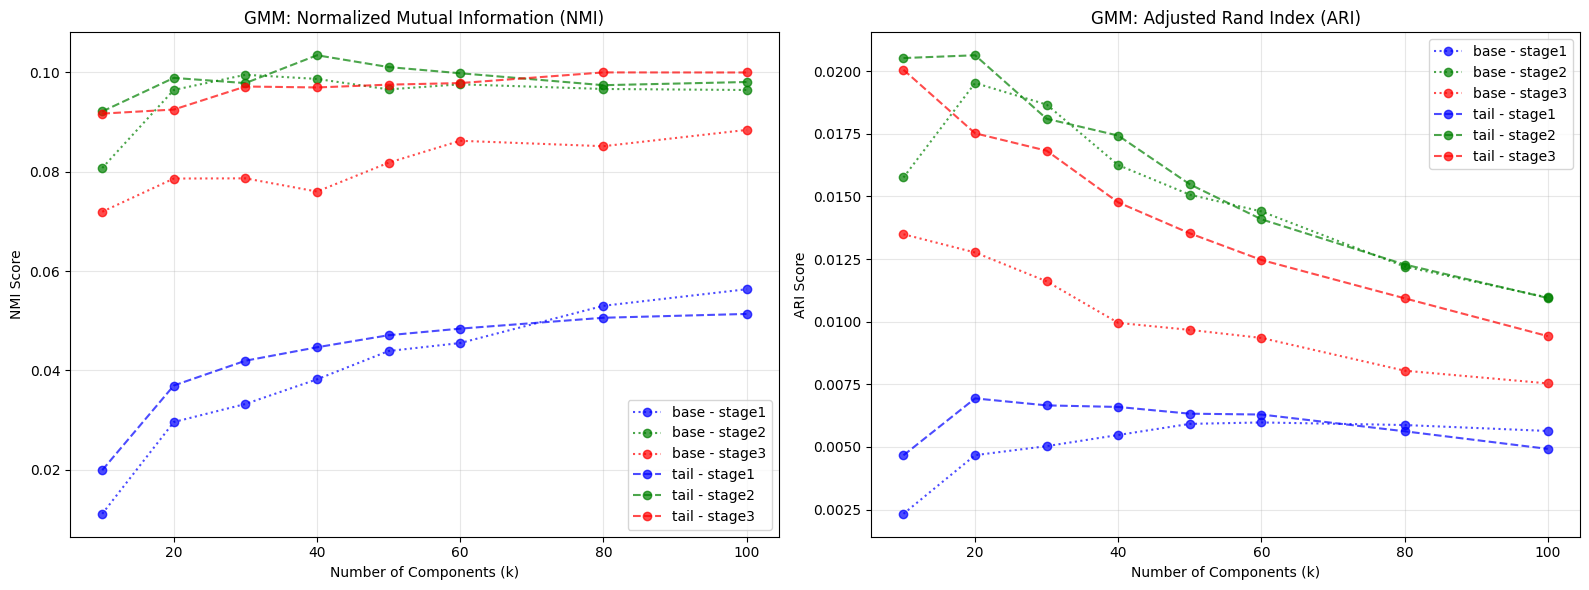

In [4]:
import json
import matplotlib.pyplot as plt
import os

from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

# Path to your archived GMM metrics
metrics_path = BASE_DIR / "archive/old_k_sweeps/gmm_metrics.json"

# Example of how to load it safely with the Path object
with open(metrics_path, "r") as f:
    gmm_results = json.load(f)

with open(metrics_path, "r") as f:
    gmm_results = json.load(f)

# Set up the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = {"stage1": "blue", "stage2": "green", "stage3": "red"}
linestyles = {"base": ":", "tail": "--", "tailhip": "-"} # Added tailhip!

# Plot data
for model_name, stages in gmm_results.items():
    for stage_name, metrics in stages.items():
        k_vals = sorted([int(k) for k in metrics["nmi"].keys()])
        
        nmi_vals = [metrics["nmi"][str(k)] for k in k_vals]
        ari_vals = [metrics["ari"][str(k)] for k in k_vals]
        
        label = f"{model_name} - {stage_name}"
        color = colors[stage_name]
        linestyle = linestyles[model_name]

        ax1.plot(
            k_vals,
            nmi_vals,
            color=color,
            linestyle=linestyle,
            marker="o",
            label=label,
            alpha=0.7,
        )

        ax2.plot(
            k_vals,
            ari_vals,
            color=color,
            linestyle=linestyle,
            marker="o",
            label=label,
            alpha=0.7,
        )

# Formatting
ax1.set_title("GMM: Normalized Mutual Information (NMI)")
ax1.set_xlabel("Number of Components (k)")
ax1.set_ylabel("NMI Score")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_title("GMM: Adjusted Rand Index (ARI)")
ax2.set_xlabel("Number of Components (k)")
ax2.set_ylabel("ARI Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import h5py
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Load your data (Assuming we are testing the 'tail' model, Stage 2)
# You will need to align your embeddings (X) with your KPMS labels (y) 
# just like you did in the Global Confusion Matrix cell earlier.

# Placeholder for your aligned data:
# X = global_y_hbmae_embeddings (shape: [N_frames, 192])
# y = global_y_kpms (shape: [N_frames])

print(f"Dataset size: {X.shape[0]} frames.")

# 2. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the embeddings
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train a Linear Classifier
# Using 'saga' solver as it is fast for large datasets; n_jobs=-1 uses all CPU cores
print("Training Linear Probe (Logistic Regression)...")
clf = LogisticRegression(max_iter=500, solver='saga', multi_class='multinomial', n_jobs=-1)
clf.fit(X_train_scaled, y_train)

# 5. Evaluate
y_pred = clf.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Linear Probe Accuracy: {acc * 100:.2f}%")
print("\nClassification Report (Top 10 Syllables):")
# Just showing a subset so it doesn't flood your console if you have 100 syllables
labels = np.unique(y_test)[:10] 
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

In [5]:
import h5py
import pandas as pd
import numpy as np

from pathlib import Path

# Safely determine BASE_DIR whether in a script or a Jupyter Notebook
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd()
    if BASE_DIR.name == "notebooks":
        BASE_DIR = BASE_DIR.parent

PROJECT_ROOT = Path("/scratch/michal/projects/dvc_ofd_2025")

# --- Configuration ---
# Point this to your finalized K=40 GMM labels
GMM_H5_PATH = BASE_DIR / "data/cluster_labels/gmm_labels_tailhip_40.h5"

# If you actually needed the old exploratory sweep data, uncomment this line instead:
# GMM_H5_PATH = BASE_DIR / "archive/old_k_sweeps/gmm_labels_tailhip.h5"

# Metadata remains in your external raw data folder
META_TSV_PATH = PROJECT_ROOT / "data/raw/openfield_ORT/hdp_meta.tsv"

STAGE = "stage3"  # Change to whichever stage you want to test
K_CLUSTERS = 40

def build_feature_matrix():
    print("1. Loading metadata TSV...")
    
    # Use '\s+' as the separator. This tells Pandas to split on ANY amount of whitespace 
    # (spaces or tabs), which is much safer for wonky text files.
    meta_df = pd.read_csv(META_TSV_PATH, sep='\s+')
    
    # Let's see what Pandas thought the columns were before we clean them
    print(f"Original TSV columns: {meta_df.columns.tolist()}")
    
    # Aggressively clean the column names: strip quotes and whitespace
    meta_df.columns = meta_df.columns.str.replace('"', '').str.strip()
    
    # Aggressively clean the animal_id strings
    meta_df['animal_id'] = meta_df['animal_id'].astype(str).str.replace('"', '').str.strip()
    
    print(f"Cleaned TSV columns: {meta_df.columns.tolist()}")
    
    # ... (The rest of the script starting from "2. Extracting frequencies..." remains the same)

    print(f"2. Extracting frequencies from {GMM_H5_PATH}...")
    features_list = []
    
    with h5py.File(GMM_H5_PATH, 'r') as f:
        video_names = list(f.keys())
        print(f"  -> Found {len(video_names)} total videos in H5 file.")
        
        if len(video_names) > 0:
            print(f"  -> Preview of first video name: '{video_names[0]}'")
            
        for vid in video_names:
            parts = vid.split('_')
            
            # If the name doesn't have at least 3 parts, print a warning for the first one and skip
            if len(parts) < 3:
                if vid == video_names[0]:
                    print(f"  -> WARNING: '{vid}' does not match expected format (needs at least 2 underscores). Skipping.")
                continue 
                
            animal_id = parts[0]
            exp_stage = parts[1]
            age = parts[2]
            
            dataset_path = f"{vid}/{STAGE}/k_{K_CLUSTERS}"
            
            # Check if the dataset path exists
            if dataset_path not in f:
                if vid == video_names[0]:
                    print(f"  -> WARNING: Path '{dataset_path}' not found in H5. Skipping.")
                continue
                
            labels = f[dataset_path][:]
            
            counts = np.bincount(labels, minlength=K_CLUSTERS)
            freqs = counts / len(labels) 
            
            row_data = {
                'video_name': vid,
                'animal_id': animal_id,
                'exp_stage': exp_stage,
                'age': age
            }
            
            for i in range(K_CLUSTERS):
                row_data[f'cluster_{i}'] = freqs[i]
                
            features_list.append(row_data)

    if len(features_list) == 0:
        raise ValueError("\nERROR: features_list is empty! None of the videos in the H5 file successfully matched our parsing rules and contained the GMM labels.")
        
    freq_df = pd.DataFrame(features_list)
    print(f"  -> Successfully extracted features for {len(freq_df)} videos.")
    
    print("3. Merging frequencies with TSV metadata...")
    # Merge based on the 'animal_id' column
    master_df = pd.merge(freq_df, meta_df, on='animal_id', how='inner')
    
    print(f"Successfully built master table with {master_df.shape[0]} rows and {master_df.shape[1]} columns!")
    return master_df

if __name__ == "__main__":
    df = build_feature_matrix()
    
    # Let's peek at the final merged data
    print("\nMaster Table Preview:")
    print(df[['video_name', 'strain', 'age', 'exp_stage', 'cluster_0', 'cluster_1']].head())
    
    # Save it so we can easily load it into our classifier next
    df.to_csv("master_features_tailhip_stage3.csv", index=False)
    print("\nSaved to master_features_tailhip_stage3.csv")

1. Loading metadata TSV...
Original TSV columns: ['animal_id', 'strain', 'sex', 'cohort', 'treatment', 'owner']
Cleaned TSV columns: ['animal_id', 'strain', 'sex', 'cohort', 'treatment', 'owner']
2. Extracting frequencies from /scratch/michal/projects/dvc_ofd_2025/code/BehaveMAE_reconstruction/extract_embeding_folder_kptmsq/data/cluster_labels/gmm_labels_tailhip_40.h5...
  -> Found 3224 total videos in H5 file.
  -> Preview of first video name: 'HDP-002539_HAB_Adult_371'
  -> Successfully extracted features for 3224 videos.
3. Merging frequencies with TSV metadata...
Successfully built master table with 3224 rows and 49 columns!

Master Table Preview:
                 video_name   strain    age exp_stage  cluster_0  cluster_1
0  HDP-002539_HAB_Adult_371  PWK/PhJ  Adult       HAB   0.021410   0.024998
1  HDP-002539_RET_Adult_419  PWK/PhJ  Adult       RET   0.037659   0.048667
2    HDP-002539_RET_Old_391  PWK/PhJ    Old       RET   0.019308   0.016644
3   HDP-002540_ACQ_Adult_34  PWK/PhJ

In [ ]:
import h5py



with h5py.File(GMM_H5_PATH, 'r') as f:
    vid = 'HDP-002539_HAB_Adult_371'
    print(f"Contents of {vid}:")
    
    # This will recursively print the tree structure inside the video group
    f[vid].visititems(lambda name, obj: print(f"  -> {name} {'(Dataset)' if isinstance(obj, h5py.Dataset) else '(Group)'}"))

Contents of HDP-002539_HAB_Adult_371:
  -> stage1 (Group)
  -> stage1/k_10 (Dataset)
  -> stage1/k_100 (Dataset)
  -> stage1/k_20 (Dataset)
  -> stage1/k_30 (Dataset)
  -> stage1/k_40 (Dataset)
  -> stage1/k_50 (Dataset)
  -> stage1/k_60 (Dataset)
  -> stage1/k_80 (Dataset)
  -> stage2 (Group)
  -> stage2/k_10 (Dataset)
  -> stage2/k_20 (Dataset)
  -> stage2/k_30 (Dataset)
  -> stage2/k_40 (Dataset)
  -> stage2/k_50 (Dataset)
